# 01. Setup & Data Loading for Deep Analysis
We will reload our dataset and apply the datetime conversion immediately. This notebook focuses purely on how different engagement metrics scale against each other.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

# Load and prep the data
df = pd.read_csv('data/youtube.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.drop_duplicates()

print("Data loaded and ready for analysis.")

Data loaded and ready for analysis.


# 02. Engagement Dynamics: Views vs. Likes & Comments
We know there is a strong correlation (0.84) between views and likes. Now, let's visualize the actual shape of that relationship. 

Because the data is heavily skewed by mega-viral videos, plotting raw numbers will result in a clustered, unreadable mess. We will apply a log transformation to both axes to clearly see the trendline across all tiers of viewership.

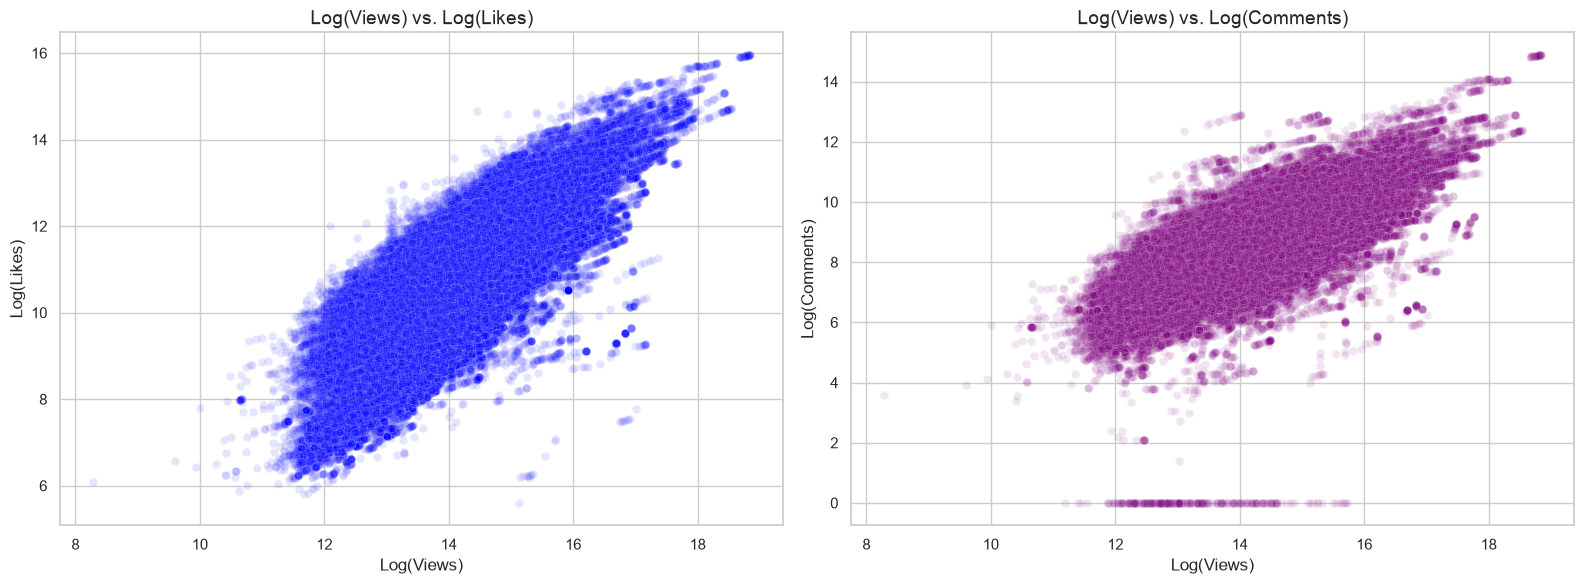

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Log(Views) vs Log(Likes)
sns.scatterplot(
    x=np.log1p(df['views']), 
    y=np.log1p(df['likes']), 
    alpha=0.1, # Transparency helps visualize density where points overlap
    color='blue',
    ax=axes[0]
)
axes[0].set_title('Log(Views) vs. Log(Likes)', fontsize=14)
axes[0].set_xlabel('Log(Views)')
axes[0].set_ylabel('Log(Likes)')

# Plot 2: Log(Views) vs Log(Comments)
sns.scatterplot(
    x=np.log1p(df['views']), 
    y=np.log1p(df['comments']), 
    alpha=0.1, 
    color='purple',
    ax=axes[1]
)
axes[1].set_title('Log(Views) vs. Log(Comments)', fontsize=14)
axes[1].set_xlabel('Log(Views)')
axes[1].set_ylabel('Log(Comments)')

plt.tight_layout()
plt.show()

# 03. Total Engagement Rate
Raw views don't tell the whole story. To measure how actively an audience participates with the content, we need to calculate the Engagement Rate. 

The formula for this is:
$$Engagement Rate = \frac{Likes + Comments + Dislikes}{Views} \times 100$$

This gives us the percentage of viewers who took a measurable action.

The median engagement rate is: 4.49%


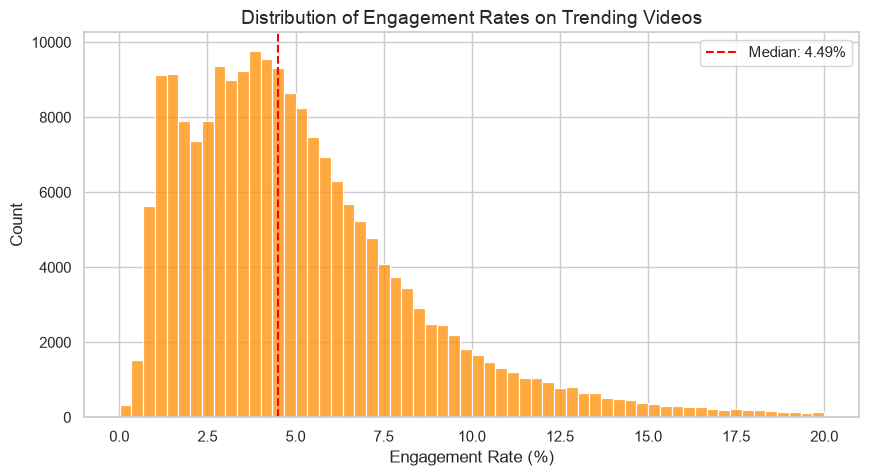

In [3]:
# Calculate Total Engagement Rate as a percentage
df['engagement_rate'] = ((df['likes'] + df['comments'] + df['dislikes']) / df['views']) * 100

# Drop any rows where views were 0 (to avoid infinity/NaN values)
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['engagement_rate'])

# Find the median engagement rate
median_engagement = df['engagement_rate'].median()
print(f"The median engagement rate is: {median_engagement:.2f}%")

# Visualize the distribution of engagement rates
plt.figure(figsize=(10, 5))
# Filtering out massive outliers (rates > 20%) just to make the chart readable
sns.histplot(df[df['engagement_rate'] < 20]['engagement_rate'], bins=60, color='darkorange')
plt.axvline(median_engagement, color='red', linestyle='--', label=f'Median: {median_engagement:.2f}%')

plt.title('Distribution of Engagement Rates on Trending Videos', fontsize=14)
plt.xlabel('Engagement Rate (%)')
plt.ylabel('Count')
plt.legend()
plt.show()

# 04. Analyzing the Top 1% of Engaging Content
What separates a standard trending video from a highly active, community-driven piece of content? Let's isolate the top 1% of videos based on their Engagement Rate and see how their baseline metrics compare to the average.

In [4]:
# Find the threshold for the 99th percentile of engagement
top_1_percent_threshold = df['engagement_rate'].quantile(0.99)

# Create a dataframe of just these elite videos
elite_engagement_df = df[df['engagement_rate'] >= top_1_percent_threshold]

print(f"Threshold for Top 1% Engagement Rate: {top_1_percent_threshold:.2f}%")
print("-" * 40)
print("AVERAGE TRENDING VIDEO:")
print(f"Median Views: {df['views'].median():,.0f}")
print(f"Median Likes: {df['likes'].median():,.0f}")
print(f"Median Comments: {df['comments'].median():,.0f}")
print("-" * 40)
print("TOP 1% ENGAGEMENT VIDEO:")
print(f"Median Views: {elite_engagement_df['views'].median():,.0f}")
print(f"Median Likes: {elite_engagement_df['likes'].median():,.0f}")
print(f"Median Comments: {elite_engagement_df['comments'].median():,.0f}")

Threshold for Top 1% Engagement Rate: 19.57%
----------------------------------------
AVERAGE TRENDING VIDEO:
Median Views: 1,091,419
Median Likes: 42,757
Median Comments: 4,036
----------------------------------------
TOP 1% ENGAGEMENT VIDEO:
Median Views: 1,396,944
Median Likes: 318,340
Median Comments: 22,516


### Key Insight on Elite Engagement
Interestingly, videos with the highest engagement rates often do not have the highest absolute view counts. When a video reaches an incredibly massive, mainstream audience, the percentage of viewers who actively interact (like or comment) naturally dilutes. The highest engagement rates usually belong to videos with a highly dedicated, core audience.

# 05. Conclusion: The Anatomy of Highly Engaging Content

Our deep dive into the engagement dynamics of trending YouTube videos reveals a critical insight for content strategy: **massive reach does not equal maximum engagement.**

By comparing the "Average" trending video against the "Top 1% Elite" trending video, we found a fascinating dynamic:
*   **Average Trending Video:** ~1.09M Views | ~42k Likes | ~4k Comments 
*   **Top 1% Elite Video:** ~1.39M Views | ~318k Likes | ~22k Comments

### Key Takeaways
1.  **The 20% Rule:** The threshold to enter the top 1% of engaging content is an astonishing **19.57% engagement rate**. This means nearly 1 in 5 viewers actively liked or commented, compared to the platform baseline of around 4-5%.
2.  **The View Count is a Baseline, Not the Ceiling:** These elite videos don't necessarily have tens of millions of views. They sit right next to average trending videos in viewership (~1.39M vs ~1.09M) but generate **over 7x the likes and 5.5x the comments**. 
3.  **Community Over Casuals:** The highest engagement rates belong to content that speaks directly to a core community. When a video reaches an incredibly massive, mainstream audience, the relative percentage of active interactions naturally dilutes.
4.  **The Strategic Value:** If the goal is raw brand awareness, maximizing views is sufficient. However, if the goal is community building, conversions, or audience loyalty, creators must focus on content that drives that 7x interaction multiplier within the 1-to-2 million view "sweet spot."